<a href="https://colab.research.google.com/github/makarand-13/Machine-Learning-Lab/blob/main/MLEX7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : makrand sanjay sarang

Batch : c3


Roll Number :ce41



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [12]:
# Import core Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from google.colab import files

uploaded = files.upload()


df = pd.read_csv("data.csv")

df.head()

# Display the first 5 rows
df.head()


Saving data.csv to data (1).csv


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

In [13]:
# 1. Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# 2. Dataset summary statistics
print("\nSummary statistics:")
display(df.describe())

# 3. Check column data types
print("\nColumn data types:")
print(df.dtypes)

# 4. Inspect target class distribution
print("\nDiagnosis class distribution:")
print(df["diagnosis"].value_counts())

# 5. Inspect target class distribution as percentages
print("\nDiagnosis class distribution (%):")
print(df["diagnosis"].value_counts(normalize=True) * 100)


Missing values in each column:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



Column data types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64


# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [14]:
# Drop metadata columns
df = df.drop(columns=["id", "Unnamed: 32"])

# Convert diagnosis: M = 1 (Malignant), B = 0 (Benign)
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Separate features (X) and target (y)
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Check the results
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())


X shape: (569, 30)
y shape: (569,)

Feature columns:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Target distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [15]:
from sklearn.preprocessing import StandardScaler

# Create the StandardScaler
scaler = StandardScaler()

# Fit the scaler and transform the features
X_scaled = scaler.fit_transform(X)

# Convert back to a DataFrame for easier inspection
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

# Check the result
print("Scaled feature shape:", X_scaled.shape)

print("\nMeans (approximately 0):")
print(X_scaled.mean().round(6))

print("\nStandard deviations (approximately 1):")
print(X_scaled.std(ddof=0).round(6))


Scaled feature shape: (569, 30)

Means (approximately 0):
radius_mean               -0.0
texture_mean               0.0
perimeter_mean            -0.0
area_mean                 -0.0
smoothness_mean           -0.0
compactness_mean           0.0
concavity_mean             0.0
concave points_mean       -0.0
symmetry_mean              0.0
fractal_dimension_mean     0.0
radius_se                  0.0
texture_se                -0.0
perimeter_se              -0.0
area_se                   -0.0
smoothness_se             -0.0
compactness_se             0.0
concavity_se               0.0
concave points_se          0.0
symmetry_se                0.0
fractal_dimension_se      -0.0
radius_worst              -0.0
texture_worst              0.0
perimeter_worst           -0.0
area_worst                 0.0
smoothness_worst          -0.0
compactness_worst         -0.0
concavity_worst            0.0
concave points_worst       0.0
symmetry_worst             0.0
fractal_dimension_worst   -0.0
dtype: float

# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [16]:
from sklearn.decomposition import PCA

# Create PCA with 2 principal components
pca = PCA(n_components=2)

# Fit PCA and transform the standardized data
X_pca = pca.fit_transform(X_scaled)

# Convert to DataFrame
X_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=X_scaled.index
)

# Check the transformed data
print("PCA shape:", X_pca.shape)
print("\nFirst 5 observations:")
print(X_pca.head())


PCA shape: (569, 2)

First 5 observations:
        PC1        PC2
0  9.192837   1.948583
1  2.387802  -3.768172
2  5.733896  -1.075174
3  7.122953  10.275589
4  3.935302  -1.948072


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


In [17]:
# Variance explained by each principal component
pc1_variance = pca.explained_variance_ratio_[0]
pc2_variance = pca.explained_variance_ratio_[1]

# Cumulative variance retained
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Print results
print(f"PC1 variance explained: {pc1_variance:.4f} ({pc1_variance * 100:.2f}%)")
print(f"PC2 variance explained: {pc2_variance:.4f} ({pc2_variance * 100:.2f}%)")
print(f"Cumulative variance retained: {cumulative_variance[-1]:.4f} "
      f"({cumulative_variance[-1] * 100:.2f}%)")


PC1 variance explained: 0.4427 (44.27%)
PC2 variance explained: 0.1897 (18.97%)
Cumulative variance retained: 0.6324 (63.24%)


# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

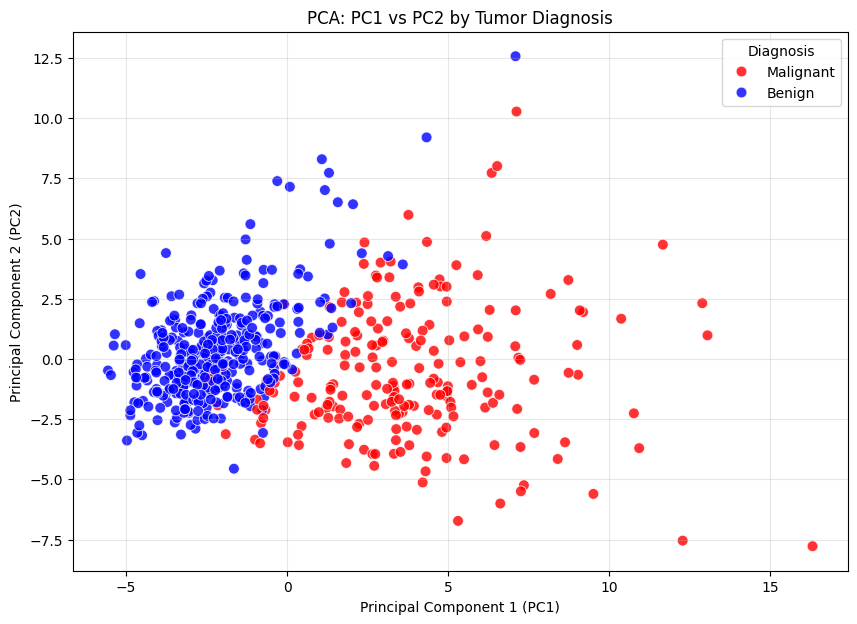

In [18]:
# Create readable diagnosis labels
diagnosis_labels = y.map({
    0: "Benign",
    1: "Malignant"
})

# Create 2D PCA scatter plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_pca["PC1"],
    y=X_pca["PC2"],
    hue=diagnosis_labels,
    palette={
        "Benign": "blue",
        "Malignant": "red"
    },
    s=60,
    alpha=0.8
)

plt.title("PCA: PC1 vs PC2 by Tumor Diagnosis")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title="Diagnosis")
plt.grid(alpha=0.3)
plt.show()


# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Split the original scaled 30-feature dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)

# Baseline performance metrics
print("Baseline Logistic Regression Performance")
print("----------------------------------------")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Detailed classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Benign", "Malignant"]
))


Baseline Logistic Regression Performance
----------------------------------------
Accuracy : 0.9649
Precision: 0.9750
Recall   : 0.9286
F1-score : 0.9512

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split the 2-component PCA dataset
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train Logistic Regression using only PC1 and PC2
pca_log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

pca_log_reg.fit(X_pca_train, y_pca_train)

# Make predictions
y_pca_pred = pca_log_reg.predict(X_pca_test)

# Check dimensions
print("Training set shape:", X_pca_train.shape)
print("Testing set shape :", X_pca_test.shape)

print("\nModel trained using:")
print(X_pca.columns.tolist())


Training set shape: (455, 2)
Testing set shape : (114, 2)

Model trained using:
['PC1', 'PC2']


# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



In [21]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# =========================
# 1. Predictions
# =========================

# Before PCA: 30-feature model
y_pred_30 = log_reg.predict(X_test)

# After PCA: 2-component model
y_pred_pca = pca_log_reg.predict(X_pca_test)


# =========================
# 2. Accuracy Scores
# =========================

accuracy_30 = accuracy_score(y_test, y_pred_30)
accuracy_pca = accuracy_score(y_pca_test, y_pred_pca)

print("Accuracy Comparison")
print("-------------------")
print(f"30 Features : {accuracy_30:.4f}")
print(f"2 PCA Components: {accuracy_pca:.4f}")


# =========================
# 3. Confusion Matrices
# =========================

print("\nConfusion Matrix - 30 Features")
print(confusion_matrix(y_test, y_pred_30))

print("\nConfusion Matrix - 2 PCA Components")
print(confusion_matrix(y_pca_test, y_pca_pred))


# =========================
# 4. Classification Reports
# =========================

print("\nClassification Report - 30 Features")
print(classification_report(
    y_test,
    y_pred_30,
    target_names=["Benign", "Malignant"]
))

print("\nClassification Report - 2 PCA Components")
print(classification_report(
    y_pca_test,
    y_pca_pred,
    target_names=["Benign", "Malignant"]
))


Accuracy Comparison
-------------------
30 Features : 0.9649
2 PCA Components: 0.9386

Confusion Matrix - 30 Features
[[71  1]
 [ 3 39]]

Confusion Matrix - 2 PCA Components
[[71  1]
 [ 6 36]]

Classification Report - 30 Features
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Classification Report - 2 PCA Components
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.